# Exploratory Data Analysis

### The goal is to understand the merged FBref - Transfermarkt dataset before modeling

Questions answered in this notebook:

1. How skewed is market value (this drives the choice to log-transform the target variable)? 

2. Which performance stats correlate with price?

3. Is there a league premium (the "Premier League Tax")?

4. How does value vary by position?

5. What's the age-vs-value curve?

In [36]:
## Importing dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
## Reading in the dataset, transforming some variables, taking a look

sns.set_theme(style='whitegrid', context='notebook')

df = pd.read_csv('../data/processed/final_dataset.csv')
df['age_clean'] = df['age'].astype(str).str.split('-').str[0].astype(int)
df['position_primary'] = df['position'].astype(str).str.split(',').str[0]
df['value_eur_m'] = df['value_eur'] / 1_000_000

print(f'Dataset: {len(df)} players, {df.shape[1]} columns')
df.head(3)

Dataset: 405 players, 44 columns


,rank,player_name,nation,position,team,league,age,Unnamed: 7_level_0_Born,Playing Time_MP,Playing Time_Starts,...,Per 90 Minutes_xG+xAG,Per 90 Minutes_npxG,Per 90 Minutes_npxG+xAG,Unnamed: 37_level_0_Matches,name_key,value_eur,age_tm,age_clean,position_primary,value_eur_m
0,8,Matthis Abline,fr FRA,"FW,MF",Nantes,fr Ligue 1,22-241,2003.0,13,10,...,0.37,0.20,0.30,Matches,matthis abline,22000000.0,22.0,22,FW,22.0
1,23,Karim Adeyemi,de GER,"MF,FW",Dortmund,de Bundesliga,23-310,2002.0,11,7,...,0.67,0.40,0.67,Matches,karim adeyemi,60000000.0,23.0,23,MF,60.0
2,24,Simon Adingra,ci CIV,"FW,MF",Sunderland,eng Premier League,23-327,2002.0,8,4,...,0.22,0.04,0.22,Matches,simon adingra,25000000.0,23.0,23,FW,25.0


## 1. Market value is heavily right-skewed

A handful of players with high market value (>€150M) dominate the right tail. Linear models on raw € will be pulled by these outliers — log-transforming makes the target roughly symmetric.

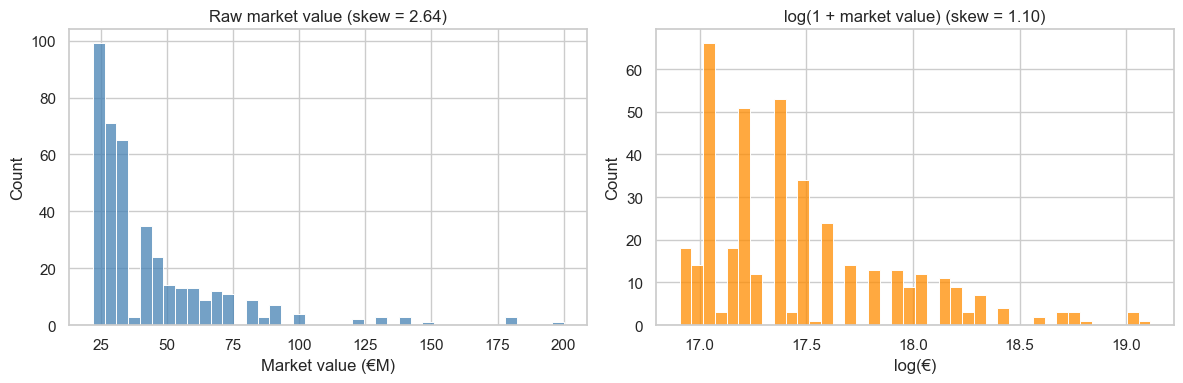

In [38]:
## Plotting the distributions of raw and log-transformed market value

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['value_eur_m'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title(f'Raw market value (skew = {df["value_eur"].skew():.2f})')
axes[0].set_xlabel('Market value (€M)')

log_value = np.log1p(df['value_eur']) # transforming with np.log1p() guarantees 0 and really small values to be nice and valid
sns.histplot(log_value, bins=40, ax=axes[1], color='darkorange')
axes[1].set_title(f'log(1 + market value) (skew = {log_value.skew():.2f})')
axes[1].set_xlabel('log(€)')
plt.tight_layout()
plt.show()

## 2. Correlation of performance stats with log-value

Expected assists (xAG), actual goals, and expected goals are the strongest single-feature signals (all ~0.36 correlation). Age shows almost no relationship with market value (r ≈ −0.01).

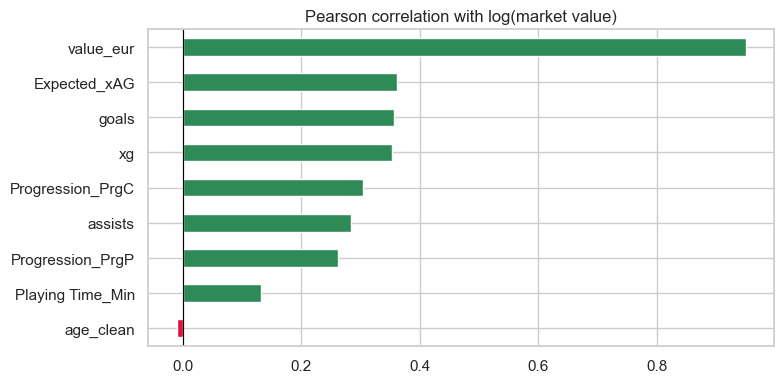

value_eur           0.949917
Expected_xAG        0.361008
goals               0.357106
xg                  0.353384
Progression_PrgC    0.304756
assists             0.283195
Progression_PrgP    0.262446
Playing Time_Min    0.132646
age_clean          -0.010412
Name: log_value, dtype: float64


In [39]:
## Correlation plot for the numeric features

numeric_features = ['age_clean', 'goals', 'assists', 'xg', 'Expected_xAG',
                    'Progression_PrgC', 'Progression_PrgP', 'Playing Time_Min']
corr = df[numeric_features + ['value_eur']].assign(log_value=np.log1p(df['value_eur'])).corr()['log_value'].drop('log_value').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
corr.plot.barh(ax=ax, color=['crimson' if c < 0 else 'seagreen' for c in corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation with log(market value)')
plt.tight_layout()
plt.show()
print(corr.sort_values(ascending=False))

## 3. League premium: is there a "Premier League Tax"?

Comparing median and mean market value per league, and looking at goals + age median too.

In [40]:
## Table for the metrics mentioned in the description

by_league = df.groupby('league').agg(
    n=('player_name', 'size'),
    median_value_eur=('value_eur', 'median'),
    mean_value_eur=('value_eur', 'mean'),
    median_goals=('goals', 'median'),
    median_age=('age_clean', 'median'),
).sort_values('median_value_eur', ascending=False)
by_league

,n,median_value_eur,mean_value_eur,median_goals,median_age
league,,,,,
es La Liga,56,40000000.0,5.732143e+07,1.0,24.0
eng Premier League,206,35000000.0,4.366990e+07,0.0,24.0
fr Ligue 1,29,35000000.0,4.548276e+07,1.0,23.0
de Bundesliga,46,30000000.0,3.723913e+07,1.0,24.0
it Serie A,68,30000000.0,3.654412e+07,1.0,25.5


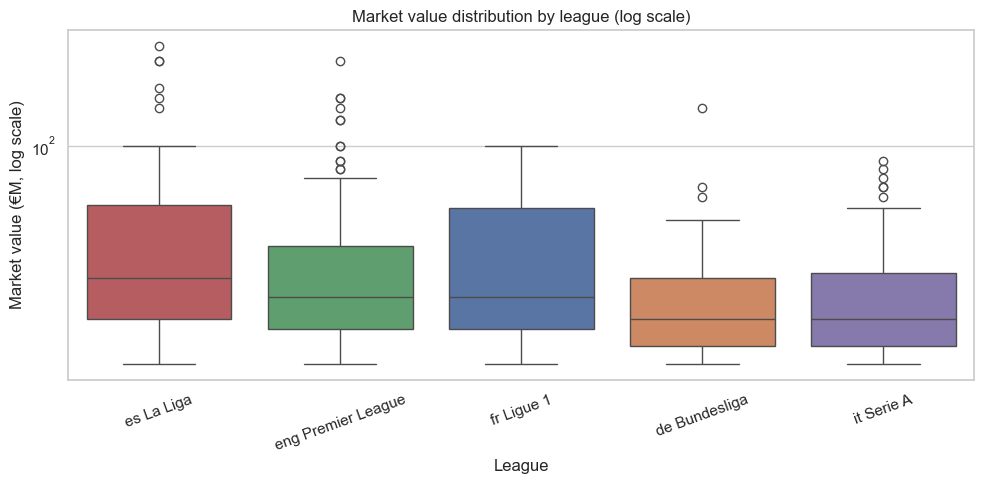

In [41]:
## Boxplots for the market value distributions by league

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='league', y='value_eur_m', ax=ax,
            order=by_league.index, hue='league')
ax.set_yscale('log')
ax.set_title('Market value distribution by league (log scale)')
ax.set_xlabel('League')
ax.set_ylabel('Market value (€M, log scale)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

La Liga's median is highest in this sample, but the Premier League has by far the biggest sample: 206 players in the top-500 globally vs. 29 from Ligue 1 for example.
The "Premier League Tax" shows up less as inflated medians and more as EPL players being priced in even when their stats wouldn't justify it elsewhere. The model in `model.py` will quantify this directly via the `league` coefficient.

## 4. Value by position

In general, forwards and midfielders have a higher market value than defenders and goalkeepers.

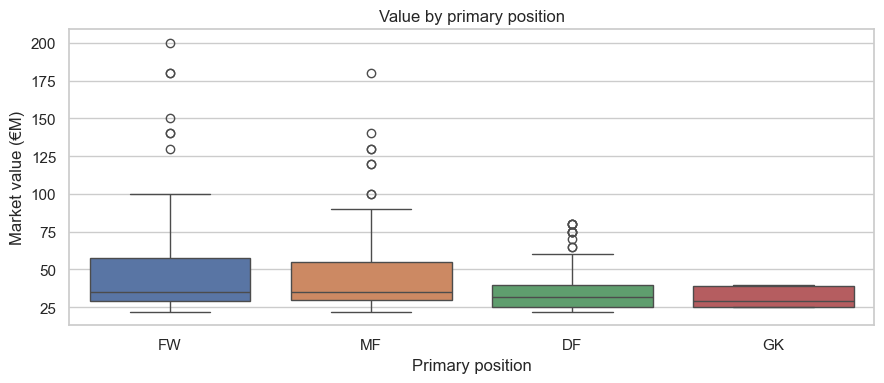

,count,median,mean
position_primary,,,
FW,127,35000000.0,4.915748e+07
MF,138,35000000.0,4.635507e+07
DF,126,32000000.0,3.686508e+07
GK,14,29000000.0,3.128571e+07


In [42]:
## Boxplots for the market value distributions by primary positions

fig, ax = plt.subplots(figsize=(9, 4))
order = df.groupby('position_primary')['value_eur_m'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='position_primary', y='value_eur_m', order=order, ax=ax, hue='position_primary')
ax.set_title('Value by primary position')
ax.set_ylabel('Market value (€M)')
ax.set_xlabel('Primary position')
plt.tight_layout()
plt.show()

df.groupby('position_primary')['value_eur'].agg(['count', 'median', 'mean']).sort_values('median', ascending=False)

## 5. Age vs value: the depreciation curve

Classic football economics somewhat visible here: peak market value in the 23–26 range, sharper drop after 30. But note the small sample.

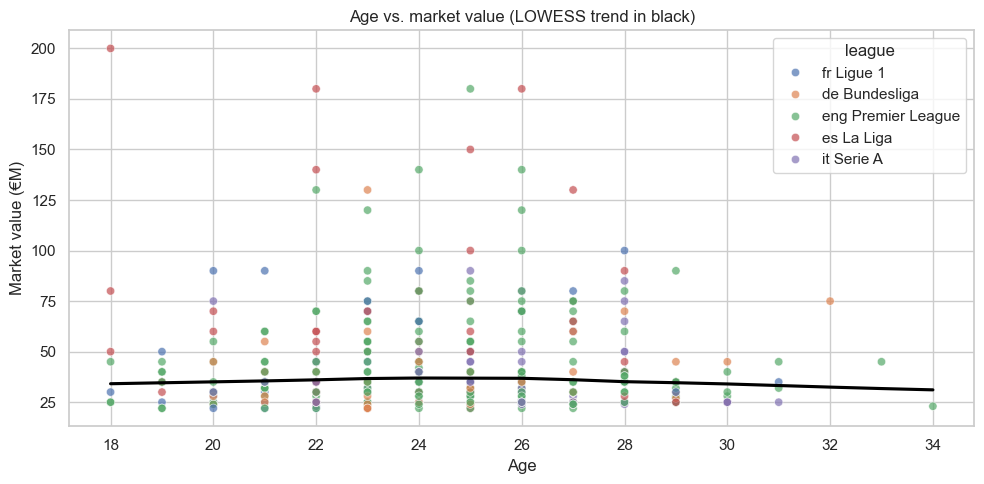

In [43]:
## Scatterplot for age vs value, with a linear regression model fit

fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df, x='age_clean', y='value_eur_m', hue='league',
                alpha=0.7, ax=ax)
sns.regplot(data=df, x='age_clean', y='value_eur_m',
            scatter=False, lowess=True, ax=ax, color='black') # this is a nonparametric model, locally weighted linear regression
ax.set_title('Age vs. market value (LOWESS trend in black)')
ax.set_xlabel('Age')
ax.set_ylabel('Market value (€M)')
plt.tight_layout()
plt.show()

## Takeaways for modeling

1. **I will log-transform the target**, because raw skew of 2.6 dropped to 1.1 in log space,
2. **League and position must be features**, since they explain a large chunk of the variance the numeric stats can't,
3. **Small N (405)** favors regularized linear models (Ridge) over high-variance tree ensembles. This is confirmed empirically in `model.py`: even after grid-search tuning, Ridge (R² = 0.25) beats RandomForest (0.08) and GradientBoosting (0.04). See `02_modeling.ipynb` for the full tuning analysis.